# Phase 1: Domain Research + Dataset + EDA + Baseline
## Legal Contract Analyzer — Unfair Clause Detection
**Date:** 2026-04-13  
**Researcher:** Anthony Rodrigues

### Research Question
Can we automatically detect unfair/risky clauses in legal contracts? We use the UNFAIR-ToS dataset (LexGLUE benchmark, ACL 2022) which contains 5,532 sentences from Terms of Service documents, annotated for 8 types of potentially unfair clauses.

### Domain Context
- **EU Directive 93/13/EEC** defines unfair contract terms — clauses that create significant imbalance in parties' rights/obligations
- Published benchmarks: BERT-base achieves ~0.83 micro-F1, Legal-BERT ~0.85 micro-F1 on this task (Chalkidis et al., ACL 2022)
- Key challenge: Only 11.4% of sentences contain unfair clauses — severe class imbalance
- This is a **multi-label** task: a sentence can be flagged for multiple unfairness types simultaneously

### Primary Metric: Micro-F1
Following the LexGLUE benchmark (Chalkidis et al., 2022), we use **micro-F1** as primary metric. This is standard because:
1. The LexGLUE leaderboard ranks by micro-F1
2. Multi-label task with severe class imbalance — micro-F1 accounts for label frequency
3. Secondary metrics: macro-F1 (per-class fairness), precision, recall, subset accuracy

### The 8 Unfair Clause Types
| # | Clause Type | Legal Risk | What It Means |
|---|-------------|-----------|---------------|
| 0 | Limitation of liability | High | Company limits what they're liable for |
| 1 | Unilateral termination | High | Company can terminate your account at will |
| 2 | Unilateral change | High | Company can change terms without notice |
| 3 | Content removal | Medium | Company can remove your content |
| 4 | Contract by using | Medium | Using the service = accepting terms |
| 5 | Choice of law | Low-Medium | Company picks which jurisdiction's law applies |
| 6 | Jurisdiction | Low-Medium | Company picks where disputes are resolved |
| 7 | Arbitration | Medium-High | Forced arbitration, no class action |

### References
1. Chalkidis et al. (2022) — LexGLUE: A Benchmark Dataset for Legal Language Understanding — ACL 2022
2. Lippi et al. (2019) — CLAUDETTE: an automated detector of potentially unfair clauses in online ToS
3. EU Directive 93/13/EEC — Unfair Terms in Consumer Contracts Directive

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset
import re
import json

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load Dataset

In [2]:
# Load UNFAIR-ToS from LexGLUE benchmark
ds = load_dataset('coastalcph/lex_glue', 'unfair_tos')
print(f'Dataset splits: {ds}')
print(f'\nFeatures: {ds["train"].features}')

LABEL_NAMES = [
    'Limitation of liability',
    'Unilateral termination', 
    'Unilateral change',
    'Content removal',
    'Contract by using',
    'Choice of law',
    'Jurisdiction',
    'Arbitration'
]

# Convert to DataFrames
def ds_to_df(split):
    df = pd.DataFrame(split)
    # Create binary columns for each label
    for i, name in enumerate(LABEL_NAMES):
        df[name] = df['labels'].apply(lambda x: 1 if i in x else 0)
    df['has_unfair'] = df['labels'].apply(lambda x: 1 if len(x) > 0 else 0)
    df['n_labels'] = df['labels'].apply(len)
    df['text_len'] = df['text'].apply(len)
    df['word_count'] = df['text'].apply(lambda x: len(x.split()))
    return df

train_df = ds_to_df(ds['train'])
val_df = ds_to_df(ds['validation'])
test_df = ds_to_df(ds['test'])

print(f'\nTrain: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')
print(f'Total: {len(train_df) + len(val_df) + len(test_df)}')

Dataset splits: DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 5532
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 1607
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 2275
    })
})

Features: {'text': Value('string'), 'labels': List(ClassLabel(names=['Limitation of liability', 'Unilateral termination', 'Unilateral change', 'Content removal', 'Contract by using', 'Choice of law', 'Jurisdiction', 'Arbitration']))}

Train: 5532, Val: 2275, Test: 1607
Total: 9414


## 2. Dataset Overview & Statistics

In [3]:
# Dataset statistics table
stats = {
    'Metric': [
        'Total samples', 'Train / Val / Test',
        'Unfair clauses (train)', 'Fair clauses (train)',
        'Imbalance ratio', 'Unique unfairness types',
        'Multi-label samples (train)', 'Avg text length (chars)',
        'Avg word count', 'Median word count',
        'Max word count', 'Min word count'
    ],
    'Value': [
        f'{len(train_df) + len(val_df) + len(test_df):,}',
        f'{len(train_df):,} / {len(val_df):,} / {len(test_df):,}',
        f'{train_df["has_unfair"].sum()} ({train_df["has_unfair"].mean()*100:.1f}%)',
        f'{(~train_df["has_unfair"].astype(bool)).sum()} ({(1-train_df["has_unfair"].mean())*100:.1f}%)',
        f'{(~train_df["has_unfair"].astype(bool)).sum() / max(train_df["has_unfair"].sum(),1):.1f}:1 (fair:unfair)',
        '8',
        f'{(train_df["n_labels"] > 1).sum()} ({(train_df["n_labels"] > 1).mean()*100:.1f}%)',
        f'{train_df["text_len"].mean():.0f}',
        f'{train_df["word_count"].mean():.0f}',
        f'{train_df["word_count"].median():.0f}',
        f'{train_df["word_count"].max()}',
        f'{train_df["word_count"].min()}'
    ]
}

stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

                     Metric                 Value
              Total samples                 9,414
         Train / Val / Test 5,532 / 2,275 / 1,607
     Unfair clauses (train)           630 (11.4%)
       Fair clauses (train)          4902 (88.6%)
            Imbalance ratio   7.8:1 (fair:unfair)
    Unique unfairness types                     8
Multi-label samples (train)             63 (1.1%)
    Avg text length (chars)                   179
             Avg word count                    32
          Median word count                    26
             Max word count                   441
             Min word count                     6


In [4]:
# Per-label distribution across splits
print('=== Label Distribution Across Splits ===')
print(f'{"Label":<28} {"Train":>8} {"Val":>8} {"Test":>8} {"Total":>8}')
print('-' * 60)
for i, name in enumerate(LABEL_NAMES):
    tr = train_df[name].sum()
    va = val_df[name].sum()
    te = test_df[name].sum()
    print(f'{name:<28} {tr:>8} {va:>8} {te:>8} {tr+va+te:>8}')
print('-' * 60)
print(f'{"ANY UNFAIR":<28} {train_df["has_unfair"].sum():>8} {val_df["has_unfair"].sum():>8} {test_df["has_unfair"].sum():>8}')
print(f'{"FAIR (no labels)":<28} {(~train_df["has_unfair"].astype(bool)).sum():>8} {(~val_df["has_unfair"].astype(bool)).sum():>8} {(~test_df["has_unfair"].astype(bool)).sum():>8}')

=== Label Distribution Across Splits ===
Label                           Train      Val     Test    Total
------------------------------------------------------------
Limitation of liability           191       67       38      296
Unilateral termination            139       59       38      236
Unilateral change                 122       28       38      188
Content removal                    73       32       13      118
Contract by using                  76       18       23      117
Choice of law                      39       18       13       70
Jurisdiction                       34       18       16       68
Arbitration                        28        9        7       44
------------------------------------------------------------
ANY UNFAIR                        630      230      172
FAIR (no labels)                 4902     2045     1435


## 3. Exploratory Data Analysis

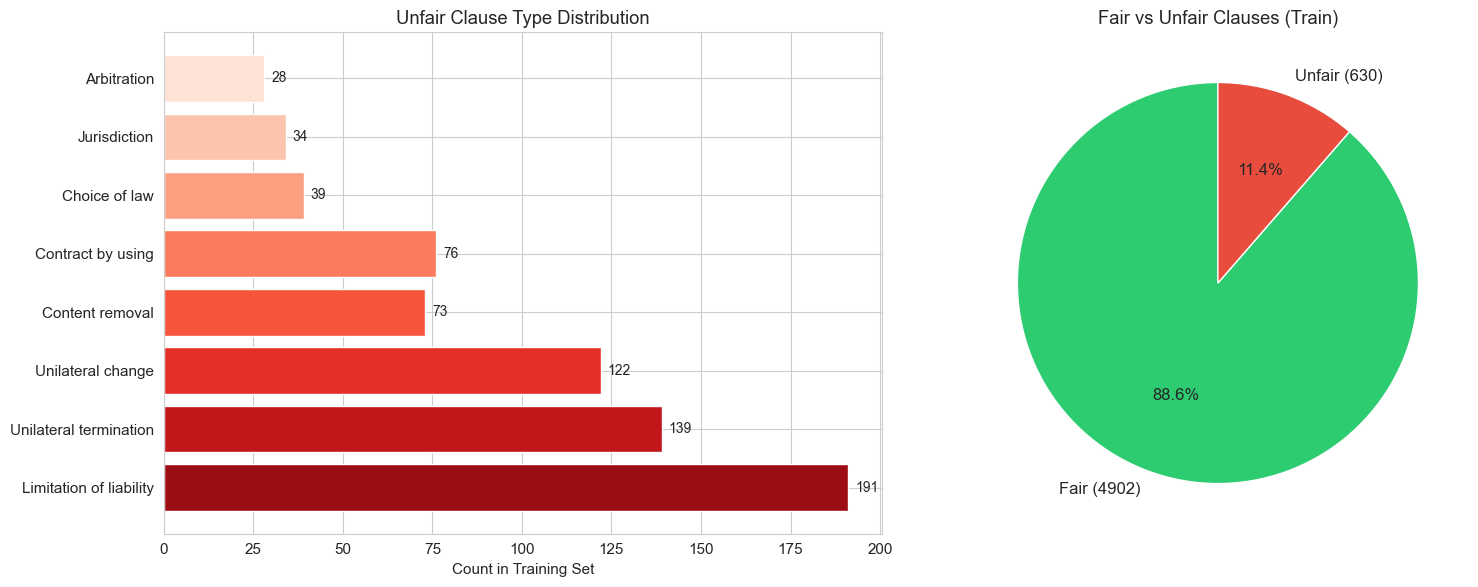

Severe imbalance: only 11.4% of sentences are unfair


In [5]:
# Plot 1: Label distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: bar chart of label counts
label_counts = [train_df[name].sum() for name in LABEL_NAMES]
colors = sns.color_palette('Reds_r', n_colors=8)
bars = axes[0].barh(LABEL_NAMES, label_counts, color=colors)
axes[0].set_xlabel('Count in Training Set')
axes[0].set_title('Unfair Clause Type Distribution')
for bar, count in zip(bars, label_counts):
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, 
                str(count), va='center', fontsize=10)

# Right: fair vs unfair pie
fair_count = (~train_df['has_unfair'].astype(bool)).sum()
unfair_count = train_df['has_unfair'].sum()
axes[1].pie([fair_count, unfair_count], 
           labels=[f'Fair ({fair_count})', f'Unfair ({unfair_count})'],
           colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
           startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Fair vs Unfair Clauses (Train)')

plt.tight_layout()
plt.savefig('../results/phase1_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Severe imbalance: only {unfair_count/(fair_count+unfair_count)*100:.1f}% of sentences are unfair')

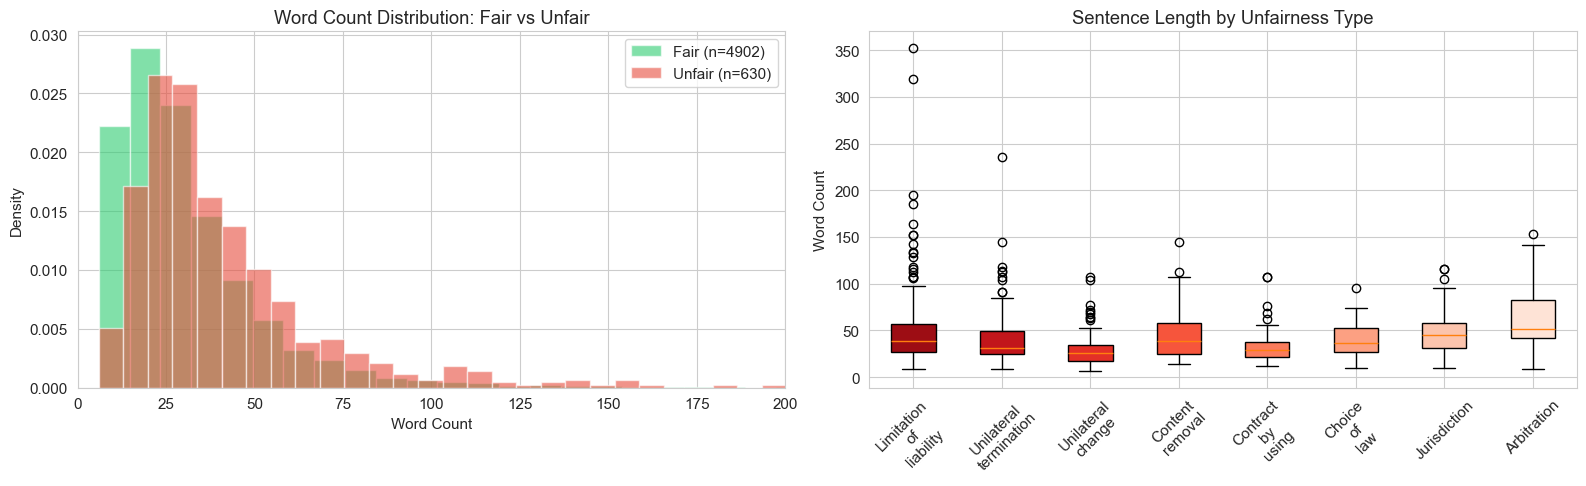

Fair sentences: median 26 words, mean 31 words
Unfair sentences: median 32 words, mean 42 words
Unfair clauses tend to be longer (mean diff: 10.7 words)


In [6]:
# Plot 2: Text length distribution by fair/unfair
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Word count distribution
fair_words = train_df[train_df['has_unfair'] == 0]['word_count']
unfair_words = train_df[train_df['has_unfair'] == 1]['word_count']

axes[0].hist(fair_words, bins=50, alpha=0.6, color='#2ecc71', label=f'Fair (n={len(fair_words)})', density=True)
axes[0].hist(unfair_words, bins=50, alpha=0.6, color='#e74c3c', label=f'Unfair (n={len(unfair_words)})', density=True)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Density')
axes[0].set_title('Word Count Distribution: Fair vs Unfair')
axes[0].legend()
axes[0].set_xlim(0, 200)

# Box plot per label
label_lengths = []
for name in LABEL_NAMES:
    lengths = train_df[train_df[name] == 1]['word_count'].values
    label_lengths.append(lengths)

bp = axes[1].boxplot(label_lengths, vert=True, patch_artist=True,
                     labels=[n.replace(' ', '\n') for n in LABEL_NAMES])
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_ylabel('Word Count')
axes[1].set_title('Sentence Length by Unfairness Type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/phase1_text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Fair sentences: median {fair_words.median():.0f} words, mean {fair_words.mean():.0f} words')
print(f'Unfair sentences: median {unfair_words.median():.0f} words, mean {unfair_words.mean():.0f} words')
print(f'Unfair clauses tend to be {"longer" if unfair_words.mean() > fair_words.mean() else "shorter"} (mean diff: {abs(unfair_words.mean() - fair_words.mean()):.1f} words)')

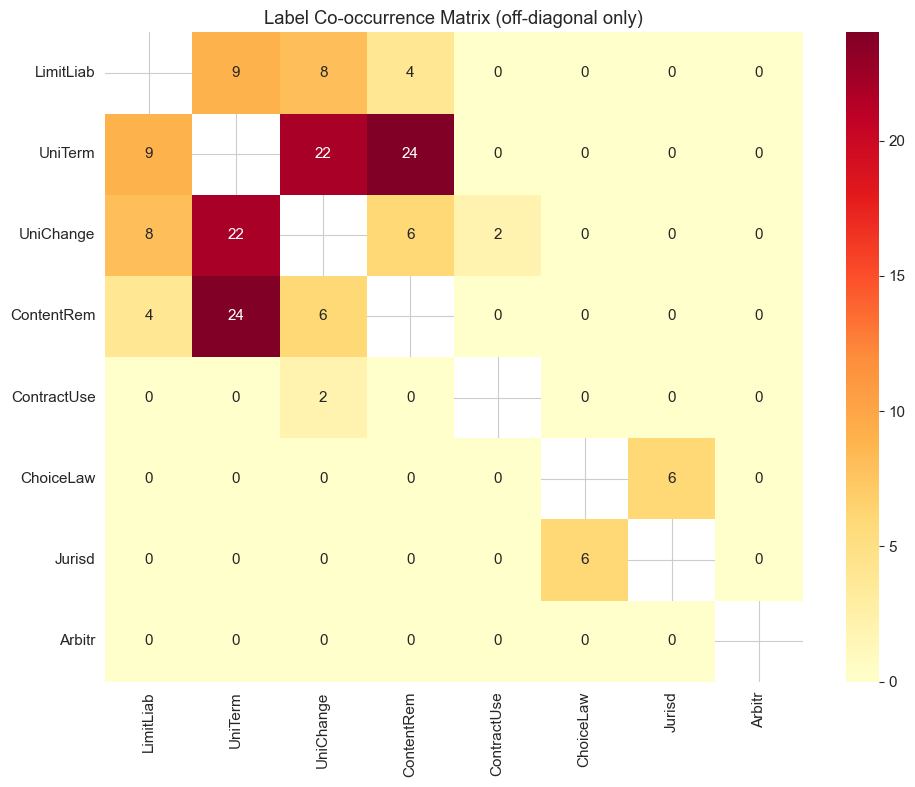

Multi-label samples: 63 (1.1%)
Distribution of label counts:
n_labels
0    4902
1     567
2      54
3       9


In [7]:
# Plot 3: Label co-occurrence matrix
# Which unfair clause types tend to appear together?
unfair_train = train_df[train_df['has_unfair'] == 1]
cooccurrence = np.zeros((8, 8), dtype=int)
for _, row in unfair_train.iterrows():
    labels = row['labels']
    for i in labels:
        for j in labels:
            cooccurrence[i][j] += 1

fig, ax = plt.subplots(figsize=(10, 8))
short_names = ['LimitLiab', 'UniTerm', 'UniChange', 'ContentRem', 
               'ContractUse', 'ChoiceLaw', 'Jurisd', 'Arbitr']
mask = np.zeros_like(cooccurrence, dtype=bool)
np.fill_diagonal(mask, True)  # mask diagonal
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd',
           xticklabels=short_names, yticklabels=short_names,
           mask=mask, ax=ax)
ax.set_title('Label Co-occurrence Matrix (off-diagonal only)')
plt.tight_layout()
plt.savefig('../results/phase1_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

# Count multi-label samples
multi = train_df[train_df['n_labels'] > 1]
print(f'Multi-label samples: {len(multi)} ({len(multi)/len(train_df)*100:.1f}%)')
print(f'Distribution of label counts:')
print(train_df['n_labels'].value_counts().sort_index().to_string())

In [8]:
# Examine sample sentences for each unfair clause type
print('=== Sample Unfair Clauses (1 per type) ===')
for i, name in enumerate(LABEL_NAMES):
    sample = train_df[train_df[name] == 1].iloc[0]['text'][:200]
    print(f'\n[{name}]:')
    print(f'  "{sample}..."')

=== Sample Unfair Clauses (1 per type) ===

[Limitation of liability]:
  "though tinder strives to encourage a respectful user experience through features like the double opt-in that only allows users to communicate if they have both indicated interest in one another , it i..."

[Unilateral termination]:
  "this means we may add new product features or enhancements from time to time as well as remove some features , and if these actions do not materially affect your rights or obligations , we may not pro..."

[Unilateral change]:
  "we may make changes to this agreement and to the services from time to time . 
..."

[Content removal]:
  "this means we may add new product features or enhancements from time to time as well as remove some features , and if these actions do not materially affect your rights or obligations , we may not pro..."

[Contract by using]:
  "by creating a tinder account or by using the tinder imessage app ( `` tinder stacks '' ) , whether through a mobile device ,

## 4. Domain-Specific Feature Engineering (EDA Phase)

Before jumping to models, let's investigate what TEXTUAL PATTERNS distinguish unfair clauses. Legal practitioners look for specific linguistic markers.

In [9]:
# Domain-informed feature engineering
# These features are based on what contract lawyers actually look for

def extract_legal_features(text):
    text_lower = text.lower()
    features = {}
    
    # 1. Power asymmetry markers (company can do X, you cannot)
    features['has_we_may'] = int(bool(re.search(r'\b(we|company|service)\s+(may|can|shall|reserve)', text_lower)))
    features['has_you_must'] = int(bool(re.search(r'\b(you|user)\s+(must|shall|agree|acknowledge)', text_lower)))
    features['has_sole_discretion'] = int('sole discretion' in text_lower or 'absolute discretion' in text_lower)
    features['has_right_to'] = int(bool(re.search(r'\breserve[s]?\s+the\s+right', text_lower)))
    
    # 2. Limitation/exclusion language
    features['has_not_liable'] = int(bool(re.search(r'\b(not|no)\s+(liable|liability|responsible|responsibility)', text_lower)))
    features['has_limitation'] = int(bool(re.search(r'\b(limit|cap|maximum|aggregate|exceed)', text_lower)))
    features['has_disclaimer'] = int(bool(re.search(r'\b(disclaim|as.is|without\s+warrant|no\s+warrant)', text_lower)))
    features['has_exclusion'] = int(bool(re.search(r'\b(exclud|except|other\s+than)', text_lower)))
    
    # 3. Unilateral change/termination markers  
    features['has_any_time'] = int('at any time' in text_lower or 'at our discretion' in text_lower)
    features['has_without_notice'] = int('without notice' in text_lower or 'without prior' in text_lower)
    features['has_modify_terms'] = int(bool(re.search(r'\b(modify|change|update|revise|amend)\s+(these|the|this|our)\s+(terms|agreement|policy|conditions)', text_lower)))
    features['has_terminate'] = int(bool(re.search(r'\b(terminat|suspend|cancel|discontinu|remov)', text_lower)))
    
    # 4. Jurisdiction/arbitration markers
    features['has_governing_law'] = int(bool(re.search(r'\b(governing\s+law|governed\s+by|laws\s+of)', text_lower)))
    features['has_arbitration'] = int(bool(re.search(r'\b(arbitrat|binding\s+arbitrat|class\s+action\s+waiver)', text_lower)))
    features['has_jurisdiction'] = int(bool(re.search(r'\b(jurisdiction|venue|court[s]?\s+of|submit\s+to)', text_lower)))
    
    # 5. Consent mechanisms
    features['has_by_using'] = int(bool(re.search(r'\bby\s+(using|accessing|visiting|continuing)', text_lower)))
    features['has_agree'] = int(bool(re.search(r'\b(you\s+agree|deemed\s+to|constitute[s]?\s+acceptance)', text_lower)))
    
    # 6. Legal intensity markers
    features['has_notwithstanding'] = int('notwithstanding' in text_lower)
    features['has_indemnif'] = int('indemnif' in text_lower)
    features['has_waive'] = int(bool(re.search(r'\bwaiv', text_lower)))
    features['has_irrevocab'] = int('irrevocab' in text_lower)
    
    # 7. Textual statistics
    features['word_count'] = len(text.split())
    features['char_count'] = len(text)
    features['avg_word_len'] = np.mean([len(w) for w in text.split()]) if text.split() else 0
    features['comma_count'] = text.count(',')
    features['semicolon_count'] = text.count(';')
    features['paren_count'] = text.count('(') + text.count(')')
    
    # 8. Total legal signal strength
    features['legal_signal_count'] = sum([
        features['has_sole_discretion'], features['has_right_to'],
        features['has_not_liable'], features['has_any_time'],
        features['has_without_notice'], features['has_arbitration'],
        features['has_governing_law'], features['has_by_using'],
        features['has_waive'], features['has_indemnif']
    ])
    
    return features

# Apply to all data
print('Extracting legal features...')
train_features = pd.DataFrame([extract_legal_features(t) for t in train_df['text']])
val_features = pd.DataFrame([extract_legal_features(t) for t in val_df['text']])
test_features = pd.DataFrame([extract_legal_features(t) for t in test_df['text']])
print(f'Extracted {len(train_features.columns)} features')
print(f'Feature names: {list(train_features.columns)}')

Extracting legal features...


Extracted 28 features
Feature names: ['has_we_may', 'has_you_must', 'has_sole_discretion', 'has_right_to', 'has_not_liable', 'has_limitation', 'has_disclaimer', 'has_exclusion', 'has_any_time', 'has_without_notice', 'has_modify_terms', 'has_terminate', 'has_governing_law', 'has_arbitration', 'has_jurisdiction', 'has_by_using', 'has_agree', 'has_notwithstanding', 'has_indemnif', 'has_waive', 'has_irrevocab', 'word_count', 'char_count', 'avg_word_len', 'comma_count', 'semicolon_count', 'paren_count', 'legal_signal_count']


In [10]:
# Analyze feature discriminative power
# For each feature, compare prevalence in fair vs unfair sentences
print('=== Feature Discriminative Power ===')
print(f'{"Feature":<25} {"Fair%":>8} {"Unfair%":>8} {"Ratio":>8} {"Useful?":>8}')
print('-' * 65)

binary_features = [c for c in train_features.columns if c.startswith('has_')]
fair_mask = train_df['has_unfair'] == 0
unfair_mask = train_df['has_unfair'] == 1

feat_power = []
for feat in binary_features:
    fair_pct = train_features.loc[fair_mask, feat].mean() * 100
    unfair_pct = train_features.loc[unfair_mask, feat].mean() * 100
    ratio = unfair_pct / max(fair_pct, 0.1)
    useful = 'YES' if ratio > 2.0 or ratio < 0.5 else 'marginal'
    feat_power.append((feat, fair_pct, unfair_pct, ratio))
    print(f'{feat:<25} {fair_pct:>7.1f}% {unfair_pct:>7.1f}% {ratio:>7.1f}x {useful:>8}')

feat_power.sort(key=lambda x: -x[3])
print(f'\nTop 5 most discriminative features:')
for feat, fp, up, ratio in feat_power[:5]:
    print(f'  {feat}: {ratio:.1f}x more common in unfair clauses')

=== Feature Discriminative Power ===
Feature                      Fair%  Unfair%    Ratio  Useful?
-----------------------------------------------------------------
has_we_may                    3.8%    16.5%     4.4x      YES
has_you_must                  9.4%    13.3%     1.4x marginal
has_sole_discretion           0.7%     8.9%    12.1x      YES
has_right_to                  1.1%    12.2%    11.5x      YES
has_not_liable                1.5%     6.3%     4.1x      YES
has_limitation                8.8%    16.2%     1.9x marginal
has_disclaimer                2.2%     1.6%     0.7x marginal
has_exclusion                 4.0%     6.5%     1.6x marginal
has_any_time                  1.1%    12.9%    12.1x      YES
has_without_notice            0.3%     9.4%    30.6x      YES
has_modify_terms              0.0%     3.0%    30.2x      YES
has_terminate                 6.0%    28.4%     4.8x      YES
has_governing_law             1.1%     5.9%     5.1x      YES
has_arbitration              

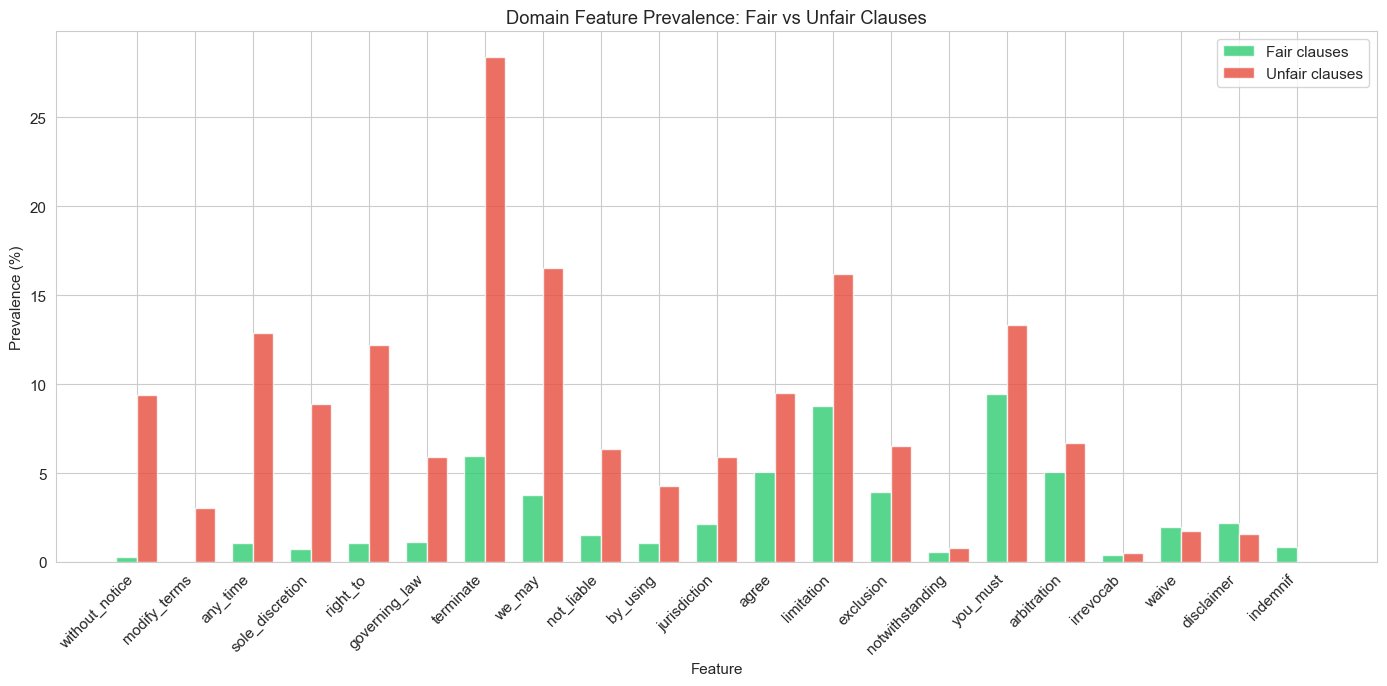

In [11]:
# Plot 4: Feature prevalence comparison
fig, ax = plt.subplots(figsize=(14, 7))

feat_names = [f[0].replace('has_', '') for f in feat_power]
fair_pcts = [f[1] for f in feat_power]
unfair_pcts = [f[2] for f in feat_power]

x = np.arange(len(feat_names))
width = 0.35
bars1 = ax.bar(x - width/2, fair_pcts, width, label='Fair clauses', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, unfair_pcts, width, label='Unfair clauses', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Feature')
ax.set_ylabel('Prevalence (%)')
ax.set_title('Domain Feature Prevalence: Fair vs Unfair Clauses')
ax.set_xticks(x)
ax.set_xticklabels(feat_names, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('../results/phase1_feature_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Baseline Models

We'll build 3 baselines:
1. **Majority class** — lower bound (predict all fair)
2. **Rule-based** — using our domain features with simple thresholds
3. **TF-IDF + Logistic Regression** — standard NLP baseline

All evaluated on the same test set using micro-F1 (primary) and macro-F1 (secondary).

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import MultiLabelBinarizer
import scipy.sparse as sp

# Prepare labels
mlb = MultiLabelBinarizer(classes=list(range(8)))
y_train = mlb.fit_transform(train_df['labels'])
y_val = mlb.transform(val_df['labels'])
y_test = mlb.transform(test_df['labels'])

print(f'Label matrix shapes — Train: {y_train.shape}, Val: {y_val.shape}, Test: {y_test.shape}')
print(f'Label distribution (train sum per class): {y_train.sum(axis=0)}')

Label matrix shapes — Train: (5532, 8), Val: (2275, 8), Test: (1607, 8)
Label distribution (train sum per class): [191 139 122  73  76  39  34  28]


In [13]:
# Baseline 1: Majority class (predict all zeros = all fair)
y_pred_majority = np.zeros_like(y_test)

micro_f1_majority = f1_score(y_test, y_pred_majority, average='micro', zero_division=0)
macro_f1_majority = f1_score(y_test, y_pred_majority, average='macro', zero_division=0)

print('=== Baseline 1: Majority Class (predict all fair) ===')
print(f'Micro-F1: {micro_f1_majority:.4f}')
print(f'Macro-F1: {macro_f1_majority:.4f}')
print('This is our absolute floor. Any model must beat this.')

=== Baseline 1: Majority Class (predict all fair) ===
Micro-F1: 0.0000
Macro-F1: 0.0000
This is our absolute floor. Any model must beat this.


In [14]:
# Baseline 2: Rule-based classifier using domain features
# Map each feature to the most likely label

def rule_based_predict(features_df):
    n = len(features_df)
    predictions = np.zeros((n, 8), dtype=int)
    
    for idx in range(n):
        row = features_df.iloc[idx]
        # Limitation of liability (0)
        if row['has_not_liable'] or row['has_limitation'] or row['has_disclaimer']:
            predictions[idx, 0] = 1
        # Unilateral termination (1)
        if row['has_terminate'] and (row['has_any_time'] or row['has_sole_discretion'] or row['has_right_to']):
            predictions[idx, 1] = 1
        # Unilateral change (2)
        if row['has_modify_terms'] or (row['has_right_to'] and row['has_any_time']):
            predictions[idx, 2] = 1
        # Content removal (3)
        if row['has_terminate'] and row['has_we_may'] and not row['has_governing_law']:
            predictions[idx, 3] = 1
        # Contract by using (4)
        if row['has_by_using'] or row['has_agree']:
            predictions[idx, 4] = 1
        # Choice of law (5)
        if row['has_governing_law']:
            predictions[idx, 5] = 1
        # Jurisdiction (6)
        if row['has_jurisdiction'] and not row['has_arbitration']:
            predictions[idx, 6] = 1
        # Arbitration (7)
        if row['has_arbitration']:
            predictions[idx, 7] = 1
    
    return predictions

y_pred_rules = rule_based_predict(test_features)

micro_f1_rules = f1_score(y_test, y_pred_rules, average='micro')
macro_f1_rules = f1_score(y_test, y_pred_rules, average='macro')
prec_rules = precision_score(y_test, y_pred_rules, average='micro')
rec_rules = recall_score(y_test, y_pred_rules, average='micro')

print('=== Baseline 2: Rule-Based Classifier ===')
print(f'Micro-F1:  {micro_f1_rules:.4f}')
print(f'Macro-F1:  {macro_f1_rules:.4f}')
print(f'Precision: {prec_rules:.4f}')
print(f'Recall:    {rec_rules:.4f}')
print()
print('Per-class performance:')
for i, name in enumerate(LABEL_NAMES):
    if y_test[:, i].sum() > 0:
        f1 = f1_score(y_test[:, i], y_pred_rules[:, i])
        prec = precision_score(y_test[:, i], y_pred_rules[:, i], zero_division=0)
        rec = recall_score(y_test[:, i], y_pred_rules[:, i], zero_division=0)
        print(f'  {name:<28} F1={f1:.3f}  P={prec:.3f}  R={rec:.3f}')

=== Baseline 2: Rule-Based Classifier ===
Micro-F1:  0.2558
Macro-F1:  0.3091
Precision: 0.1684
Recall:    0.5323

Per-class performance:
  Limitation of liability      F1=0.216  P=0.129  R=0.658
  Unilateral termination       F1=0.493  P=0.548  R=0.447
  Unilateral change            F1=0.327  P=0.529  R=0.237
  Content removal              F1=0.242  P=0.200  R=0.308
  Contract by using            F1=0.225  P=0.133  R=0.739
  Choice of law                F1=0.500  P=0.343  R=0.923
  Jurisdiction                 F1=0.383  P=0.290  R=0.562
  Arbitration                  F1=0.086  P=0.045  R=0.857


In [15]:
# Baseline 3: TF-IDF + Logistic Regression (OneVsRest)
print('Training TF-IDF + LogReg baseline...')

# TF-IDF features
tfidf = TfidfVectorizer(
    max_features=10000, 
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(train_df['text'])
X_val_tfidf = tfidf.transform(val_df['text'])
X_test_tfidf = tfidf.transform(test_df['text'])

print(f'TF-IDF feature matrix: {X_train_tfidf.shape}')

# OneVsRest Logistic Regression
lr_model = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs'),
    n_jobs=-1
)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

micro_f1_lr = f1_score(y_test, y_pred_lr, average='micro')
macro_f1_lr = f1_score(y_test, y_pred_lr, average='macro')
prec_lr = precision_score(y_test, y_pred_lr, average='micro')
rec_lr = recall_score(y_test, y_pred_lr, average='micro')

print(f'\n=== Baseline 3: TF-IDF + Logistic Regression ===')
print(f'Micro-F1:  {micro_f1_lr:.4f}')
print(f'Macro-F1:  {macro_f1_lr:.4f}')
print(f'Precision: {prec_lr:.4f}')
print(f'Recall:    {rec_lr:.4f}')
print()
print('Per-class performance:')
for i, name in enumerate(LABEL_NAMES):
    if y_test[:, i].sum() > 0:
        f1 = f1_score(y_test[:, i], y_pred_lr[:, i])
        prec = precision_score(y_test[:, i], y_pred_lr[:, i], zero_division=0)
        rec = recall_score(y_test[:, i], y_pred_lr[:, i], zero_division=0)
        print(f'  {name:<28} F1={f1:.3f}  P={prec:.3f}  R={rec:.3f}')

Training TF-IDF + LogReg baseline...


TF-IDF feature matrix: (5532, 10000)



=== Baseline 3: TF-IDF + Logistic Regression ===
Micro-F1:  0.6555
Macro-F1:  0.6729
Precision: 0.5358
Recall:    0.8441

Per-class performance:
  Limitation of liability      F1=0.653  P=0.524  R=0.868
  Unilateral termination       F1=0.667  P=0.531  R=0.895
  Unilateral change            F1=0.609  P=0.519  R=0.737
  Content removal              F1=0.480  P=0.324  R=0.923
  Contract by using            F1=0.731  P=0.655  R=0.826
  Choice of law                F1=0.857  P=0.800  R=0.923
  Jurisdiction                 F1=0.750  P=0.750  R=0.750
  Arbitration                  F1=0.636  P=0.467  R=1.000


In [16]:
# Baseline 4: TF-IDF + Domain Features combined + LogReg
# Hypothesis: Adding domain features to TF-IDF will help because they capture
# legal-specific signals that n-grams might miss
print('Training TF-IDF + Domain Features + LogReg...')

X_train_combined = sp.hstack([X_train_tfidf, sp.csr_matrix(train_features.values)])
X_val_combined = sp.hstack([X_val_tfidf, sp.csr_matrix(val_features.values)])
X_test_combined = sp.hstack([X_test_tfidf, sp.csr_matrix(test_features.values)])

print(f'Combined feature matrix: {X_train_combined.shape}')

lr_combined = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs'),
    n_jobs=-1
)
lr_combined.fit(X_train_combined, y_train)

y_pred_combined = lr_combined.predict(X_test_combined)

micro_f1_combined = f1_score(y_test, y_pred_combined, average='micro')
macro_f1_combined = f1_score(y_test, y_pred_combined, average='macro')
prec_combined = precision_score(y_test, y_pred_combined, average='micro')
rec_combined = recall_score(y_test, y_pred_combined, average='micro')

print(f'\n=== Baseline 4: TF-IDF + Domain Features + LogReg ===')
print(f'Micro-F1:  {micro_f1_combined:.4f}')
print(f'Macro-F1:  {macro_f1_combined:.4f}')
print(f'Precision: {prec_combined:.4f}')
print(f'Recall:    {rec_combined:.4f}')
print()
delta = micro_f1_combined - micro_f1_lr
print(f'Delta vs TF-IDF only: {delta:+.4f} micro-F1')
print(f'Domain features {"HELP" if delta > 0 else "HURT"} when added to TF-IDF')

Training TF-IDF + Domain Features + LogReg...
Combined feature matrix: (5532, 10028)



=== Baseline 4: TF-IDF + Domain Features + LogReg ===
Micro-F1:  0.5379
Macro-F1:  0.5166
Precision: 0.4049
Recall:    0.8011

Delta vs TF-IDF only: -0.1176 micro-F1
Domain features HURT when added to TF-IDF


In [17]:
# Baseline 5: Domain Features ONLY + LogReg
# Can domain features alone compete with 10K TF-IDF dimensions?
print('Training Domain Features Only + LogReg...')

lr_domain = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs'),
    n_jobs=-1
)
lr_domain.fit(train_features.values, y_train)

y_pred_domain = lr_domain.predict(test_features.values)

micro_f1_domain = f1_score(y_test, y_pred_domain, average='micro')
macro_f1_domain = f1_score(y_test, y_pred_domain, average='macro')
prec_domain = precision_score(y_test, y_pred_domain, average='micro')
rec_domain = recall_score(y_test, y_pred_domain, average='micro')

print(f'\n=== Baseline 5: Domain Features Only (27 features) + LogReg ===')
print(f'Micro-F1:  {micro_f1_domain:.4f}')
print(f'Macro-F1:  {macro_f1_domain:.4f}')
print(f'Precision: {prec_domain:.4f}')
print(f'Recall:    {rec_domain:.4f}')
print()
print(f'27 domain features vs 10,000 TF-IDF features:')
print(f'  Domain only:  {micro_f1_domain:.4f} micro-F1')
print(f'  TF-IDF only:  {micro_f1_lr:.4f} micro-F1')
print(f'  Ratio: {micro_f1_domain/max(micro_f1_lr,0.001)*100:.1f}% of TF-IDF performance with {27/10000*100:.2f}% of features')

Training Domain Features Only + LogReg...



=== Baseline 5: Domain Features Only (27 features) + LogReg ===
Micro-F1:  0.2146
Macro-F1:  0.2302
Precision: 0.1237
Recall:    0.8118

27 domain features vs 10,000 TF-IDF features:
  Domain only:  0.2146 micro-F1
  TF-IDF only:  0.6555 micro-F1
  Ratio: 32.7% of TF-IDF performance with 0.27% of features


## 6. Head-to-Head Comparison

In [18]:
# Master comparison table
results = [
    {'Model': 'Majority Class (all fair)', 'Micro-F1': micro_f1_majority, 'Macro-F1': macro_f1_majority, 
     'Precision': 0.0, 'Recall': 0.0, 'Features': 0, 'Type': 'Baseline'},
    {'Model': 'Rule-Based (domain)', 'Micro-F1': micro_f1_rules, 'Macro-F1': macro_f1_rules,
     'Precision': prec_rules, 'Recall': rec_rules, 'Features': 27, 'Type': 'Rules'},
    {'Model': 'TF-IDF + LogReg', 'Micro-F1': micro_f1_lr, 'Macro-F1': macro_f1_lr,
     'Precision': prec_lr, 'Recall': rec_lr, 'Features': 10000, 'Type': 'ML'},
    {'Model': 'TF-IDF + Domain + LogReg', 'Micro-F1': micro_f1_combined, 'Macro-F1': macro_f1_combined,
     'Precision': prec_combined, 'Recall': rec_combined, 'Features': 10027, 'Type': 'ML+Domain'},
    {'Model': 'Domain Only + LogReg', 'Micro-F1': micro_f1_domain, 'Macro-F1': macro_f1_domain,
     'Precision': prec_domain, 'Recall': rec_domain, 'Features': 27, 'Type': 'Domain'},
]

results_df = pd.DataFrame(results).sort_values('Micro-F1', ascending=False)
results_df.index = range(1, len(results_df)+1)
results_df.index.name = 'Rank'

print('=== Phase 1 Baseline Comparison ===')
print(results_df.to_string(float_format=lambda x: f'{x:.4f}'))

# Published benchmark comparison
print(f'\n=== vs Published Benchmarks (LexGLUE, Chalkidis et al. 2022) ===')
print(f'Our best baseline (TF-IDF+LogReg): {micro_f1_lr:.4f} micro-F1')
print(f'Published BERT-base:                ~0.83 micro-F1')
print(f'Published Legal-BERT:               ~0.85 micro-F1')
print(f'Gap to close:                       {0.83 - micro_f1_lr:+.4f}')

=== Phase 1 Baseline Comparison ===
                          Model  Micro-F1  Macro-F1  Precision  Recall  Features       Type
Rank                                                                                       
1               TF-IDF + LogReg    0.6555    0.6729     0.5358  0.8441     10000         ML
2      TF-IDF + Domain + LogReg    0.5379    0.5166     0.4049  0.8011     10027  ML+Domain
3           Rule-Based (domain)    0.2558    0.3091     0.1684  0.5323        27      Rules
4          Domain Only + LogReg    0.2146    0.2302     0.1237  0.8118        27     Domain
5     Majority Class (all fair)    0.0000    0.0000     0.0000  0.0000         0   Baseline

=== vs Published Benchmarks (LexGLUE, Chalkidis et al. 2022) ===
Our best baseline (TF-IDF+LogReg): 0.6555 micro-F1
Published BERT-base:                ~0.83 micro-F1
Published Legal-BERT:               ~0.85 micro-F1
Gap to close:                       +0.1745


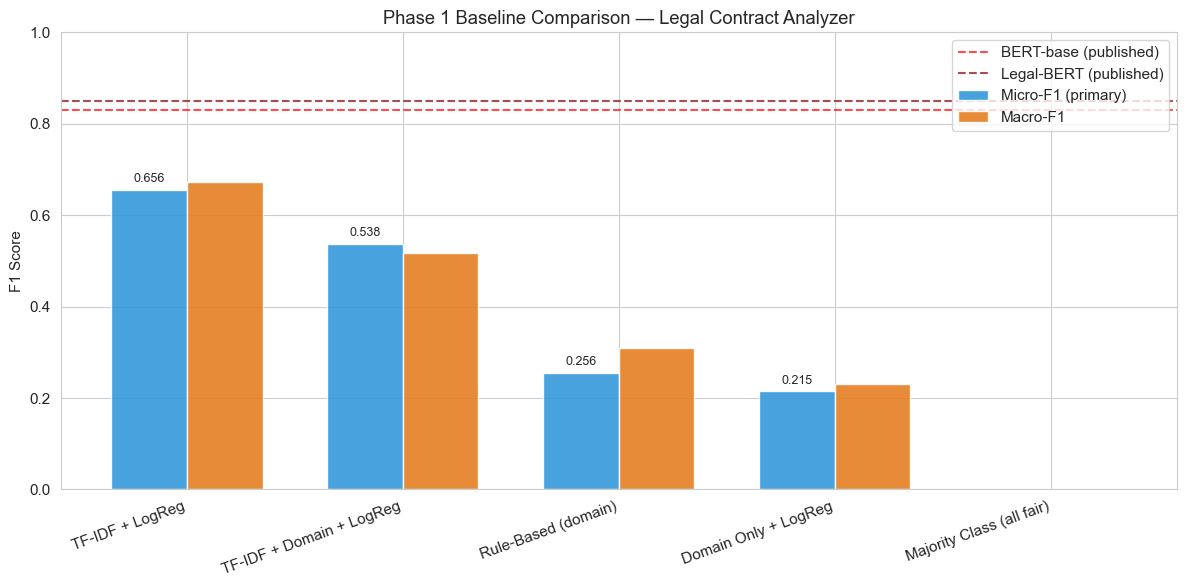

In [19]:
# Plot 5: Model comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))

models = results_df['Model'].values
micro_f1s = results_df['Micro-F1'].values
macro_f1s = results_df['Macro-F1'].values

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, micro_f1s, width, label='Micro-F1 (primary)', color='#3498db', alpha=0.9)
bars2 = ax.bar(x + width/2, macro_f1s, width, label='Macro-F1', color='#e67e22', alpha=0.9)

# Add published benchmarks as horizontal lines
ax.axhline(y=0.83, color='red', linestyle='--', alpha=0.7, label='BERT-base (published)')
ax.axhline(y=0.85, color='darkred', linestyle='--', alpha=0.7, label='Legal-BERT (published)')

ax.set_ylabel('F1 Score')
ax.set_title('Phase 1 Baseline Comparison — Legal Contract Analyzer')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 1.0)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}',
               ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/phase1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Error Analysis — What Does the Best Baseline Get Wrong?

In [20]:
# Error analysis on the best model (TF-IDF + LogReg or combined)
best_pred = y_pred_lr if micro_f1_lr >= micro_f1_combined else y_pred_combined
best_name = 'TF-IDF+LogReg' if micro_f1_lr >= micro_f1_combined else 'TF-IDF+Domain+LogReg'

# Find errors by type
print(f'=== Error Analysis: {best_name} ===')
print()

# False negatives (missed unfair clauses) — most dangerous in legal context
fn_mask = (y_test == 1) & (best_pred == 0)
fp_mask = (y_test == 0) & (best_pred == 1)

print('False Negatives (missed unfair clauses) per type:')
for i, name in enumerate(LABEL_NAMES):
    total_pos = y_test[:, i].sum()
    fn = fn_mask[:, i].sum()
    if total_pos > 0:
        print(f'  {name:<28} {fn:>3} / {total_pos:>3} missed ({fn/total_pos*100:.1f}%)')

print()
print('False Positives (flagged fair clauses as unfair) per type:')
for i, name in enumerate(LABEL_NAMES):
    total_neg = (1 - y_test[:, i]).sum()
    fp = fp_mask[:, i].sum()
    if total_neg > 0:
        print(f'  {name:<28} {fp:>3} / {total_neg:>3} false alarms ({fp/total_neg*100:.2f}%)')

=== Error Analysis: TF-IDF+LogReg ===

False Negatives (missed unfair clauses) per type:
  Limitation of liability        5 /  38 missed (13.2%)
  Unilateral termination         4 /  38 missed (10.5%)
  Unilateral change             10 /  38 missed (26.3%)
  Content removal                1 /  13 missed (7.7%)
  Contract by using              4 /  23 missed (17.4%)
  Choice of law                  1 /  13 missed (7.7%)
  Jurisdiction                   4 /  16 missed (25.0%)
  Arbitration                    0 /   7 missed (0.0%)

False Positives (flagged fair clauses as unfair) per type:
  Limitation of liability       30 / 1569 false alarms (1.91%)
  Unilateral termination        30 / 1569 false alarms (1.91%)
  Unilateral change             26 / 1569 false alarms (1.66%)
  Content removal               25 / 1594 false alarms (1.57%)
  Contract by using             10 / 1584 false alarms (0.63%)
  Choice of law                  3 / 1594 false alarms (0.19%)
  Jurisdiction              

In [21]:
# Show some false negative examples — what the model misses
print('=== Examples of Missed Unfair Clauses (False Negatives) ===')
for i, name in enumerate(LABEL_NAMES):
    fn_indices = np.where(fn_mask[:, i])[0]
    if len(fn_indices) > 0:
        idx = fn_indices[0]
        text = test_df.iloc[idx]['text'][:200]
        print(f'\nMissed [{name}]:')
        print(f'  "{text}..."')

=== Examples of Missed Unfair Clauses (False Negatives) ===

Missed [Limitation of liability]:
  "you agree that we are not responsible for others ' ( including other members ' ) content or information . 
..."

Missed [Unilateral termination]:
  "the licenses granted by amazon terminate if you do not comply with these conditions of use or any service terms . 
..."

Missed [Unilateral change]:
  "if we believe , in our sole discretion , that any member of academia.edu or academia premium or other academia.edu paid services is in breach of our terms , or act outside of the letter or spirit of o..."

Missed [Content removal]:
  "your content in memories might become unavailable for any number of reasons , including things like an operational glitch or a decision on our end to terminate your account . 
..."

Missed [Contract by using]:
  "by using any amazon service , you agree that the federal arbitration act , applicable federal law , and the laws of the state of washington , without reg

## 8. Save Results & Key Findings

In [22]:
# Save all metrics
metrics = {
    'phase': 1,
    'date': '2026-04-13',
    'dataset': 'UNFAIR-ToS (LexGLUE)',
    'primary_metric': 'micro-F1',
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'results': [
        {'model': r['Model'], 'micro_f1': round(r['Micro-F1'], 4), 
         'macro_f1': round(r['Macro-F1'], 4), 'precision': round(r['Precision'], 4),
         'recall': round(r['Recall'], 4), 'features': r['Features']}
        for _, r in results_df.iterrows()
    ],
    'published_benchmarks': {
        'BERT-base': 0.83,
        'Legal-BERT': 0.85
    }
}

with open('../results/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Results saved to results/metrics.json')
print()
print('=' * 60)
print('PHASE 1 KEY FINDINGS')
print('=' * 60)
print()
best_micro = max(micro_f1_lr, micro_f1_combined)
print(f'1. Best baseline: {best_name} with {best_micro:.4f} micro-F1')
print(f'2. Gap to published BERT-base: {0.83 - best_micro:+.4f}')
print(f'3. Gap to published Legal-BERT: {0.85 - best_micro:+.4f}')
print(f'4. Rule-based system achieves {micro_f1_rules:.4f} micro-F1 with just regex patterns')
print(f'5. 27 domain features capture {micro_f1_domain/max(best_micro,0.001)*100:.0f}% of best baseline\'s performance')
print(f'6. Severe imbalance: only {train_df["has_unfair"].mean()*100:.1f}% of sentences are unfair')
print(f'7. Domain features {"help" if micro_f1_combined > micro_f1_lr else "don\'t help"} when added to TF-IDF (delta: {micro_f1_combined - micro_f1_lr:+.4f})')
print()
print('NEXT: Phase 2 will test BERT, Legal-BERT, RoBERTa, DeBERTa to close the gap to published benchmarks.')

Results saved to results/metrics.json

PHASE 1 KEY FINDINGS

1. Best baseline: TF-IDF+LogReg with 0.6555 micro-F1
2. Gap to published BERT-base: +0.1745
3. Gap to published Legal-BERT: +0.1945
4. Rule-based system achieves 0.2558 micro-F1 with just regex patterns
5. 27 domain features capture 33% of best baseline's performance
6. Severe imbalance: only 11.4% of sentences are unfair
7. Domain features don't help when added to TF-IDF (delta: -0.1176)

NEXT: Phase 2 will test BERT, Legal-BERT, RoBERTa, DeBERTa to close the gap to published benchmarks.
